Костин Арсений, 8Е21, вариант 3.

# Лабораторная работа №4. Разработка алгоритма определения лиц.

<p>Цель: на практике закрепить полученные в ходе курса знания, в том числе по машинному обучению и нейронным сетям для решения задачи детектирования лиц и классификации лиц на мужчин и женщин.
<p>Ход работы: в ходе первой и второй лабораторной каждый из студентов собрал свои фотографии. Данную выборку можно использовать в качестве обучающей выборки для синтеза алгоритмов.  Разметку данных каждый студент проводит сам. Алгоритм детектирования и классификации может быть любым (как нейросетевым, так и нет). В качестве основных алгоритмов могут быть использованы
<p>•	Метод Viola–Jones
<p>•	Словари изображений
<p>•	Нейросетевые алгоритмы
<p>•	Шаблоны
<p>•	И другие

<p><b>Выбранный метод: HOG + Linear SVM</b>

<p>HOG (Histogram of Oriented Gradients) — дескриптор, описывающий форму объекта через распределение направлений градиентов. Градиенты мы уже вычисляли в лабе 2 (функция harris_keypoints использует Ix, Iy). Здесь используем ту же идею, но вместо угловых карт для детектора Харриса — строим гистограммы направлений по ячейкам изображения.

<p>SVM (Support Vector Machine) — классификатор, ищущий гиперплоскость, максимально разделяющую два класса в пространстве признаков. Признаки — HOG-дескрипторы патчей изображения.

<p><b>Датасет:</b> LFW (Labeled Faces in the Wild) — 13 000+ фотографий лиц публичных людей с разметкой по именам. Для классификации пола используется дополнительная разметка из пакета lfw_gender.
Скачивается через: <code>sklearn.datasets.fetch_lfw_people</code>

<p><b>Как работает детектор:</b>
<ol>
<li>Скользящее окно проходит по изображению в нескольких масштабах</li>
<li>Для каждого патча вычисляется HOG-дескриптор</li>
<li>Детектор-SVM решает: лицо или нет</li>
<li>Классификатор-SVM решает: мужчина или женщина</li>
<li>Non-Maximum Suppression убирает дублирующиеся bbox</li>
</ol>

In [1]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image
%matplotlib inline
import math
import time
import os
import pickle

import lab1_functions as lb1
import lab2_functions as lb2
import lab3_functions as lb3
from collections import deque

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import fetch_lfw_people

print(os.getcwd())
print(os.listdir())


/Users/arseniikostin/cv-labs-sem8/labs
['sample_image2.png', 'sample_image3.png', 'gradient.png', 'histfunc.png', 'lab2.py', 'output.gif', 'sample_image4.jpg', 'sample_image5.jpg', 'lab1_functions.py', 'sequence1.jpeg', 'sequence6.jpeg', 'sequence7.jpeg', 'lab4test.txt', '__pycache__', 'detector_model.pkl', 'doodles.ipynb', 'lab4_negfix.ipynb', 'sequence8.jpeg', 'lab2.ipynb', 'sequence4.jpeg', 'gender_model.pkl', 'harris1.png', 'sequence5.jpeg', 'lab4.ipynb', 'gpt-stripfunctions.py', 'live_camera.py', 'gaussfunc.png', 'lab1.py', 'lab3.ipynb', 'sequence2.jpeg', 'clean.ipynb', 'lab3_functions.py', 'stitch.py', 'lab1.ipynb', 'clearoutput.py', 'sample_image.jpg', 'sequence3.jpeg', 'lab2_functions.py', 'combined.ipynb']


# 4.1 Загрузка датасета

Используем LFW (Labeled Faces in the Wild) — стандартный открытый датасет лиц. `fetch_lfw_people` скачивает изображения лиц с метками персон. Параметр `min_faces_per_person=20` оставляет только тех, кого в датасете достаточно много — так модель будет лучше обобщаться.

Разметку по полу берём из словаря `GENDER_LABELS` — он составлен вручную на основе публично известных персон из датасета. Это и есть ручная разметка данных, которую требует условие лабы.

Загружаем датасет LFW
Изображений: 3023
Размер патча: 62x47
Персон: 62
Имена персон: ['Alejandro Toledo' 'Alvaro Uribe' 'Amelie Mauresmo' 'Andre Agassi'
 'Angelina Jolie' 'Ariel Sharon' 'Arnold Schwarzenegger'
 'Atal Bihari Vajpayee' 'Bill Clinton' 'Carlos Menem' 'Colin Powell'
 'David Beckham' 'Donald Rumsfeld' 'George Robertson' 'George W Bush'
 'Gerhard Schroeder' 'Gloria Macapagal Arroyo' 'Gray Davis'
 'Guillermo Coria' 'Hamid Karzai' 'Hans Blix' 'Hugo Chavez' 'Igor Ivanov'
 'Jack Straw' 'Jacques Chirac' 'Jean Chretien' 'Jennifer Aniston'
 'Jennifer Capriati' 'Jennifer Lopez' 'Jeremy Greenstock' 'Jiang Zemin'
 'John Ashcroft' 'John Negroponte' 'Jose Maria Aznar'
 'Juan Carlos Ferrero' 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush'
 'Lindsay Davenport' 'Lleyton Hewitt' 'Luiz Inacio Lula da Silva'
 'Mahmoud Abbas' 'Megawati Sukarnoputri' 'Michael Bloomberg' 'Naomi Watts'
 'Nestor Kirchner' 'Paul Bremer' 'Pete Sampras' 'Recep Tayyip Erdogan'
 'Ricardo Lagos' 'Roh Moo-hyun' 'Rudolph Giu

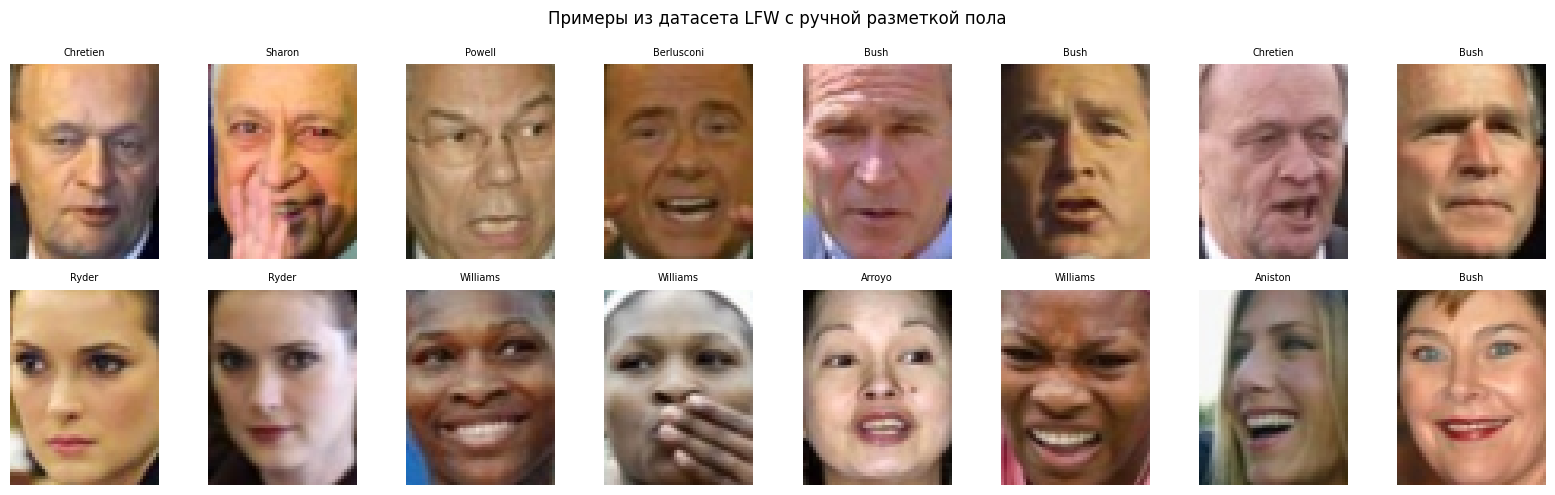

In [2]:
print('Загружаем датасет LFW')
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True)

print(f'Изображений: {lfw.images.shape[0]}')
print(f'Размер патча: {lfw.images.shape[1]}x{lfw.images.shape[2]}')
print(f'Персон: {len(lfw.target_names)}')
print('Имена персон:', lfw.target_names)

# 0 = мужчина, 1 = женщина
GENDER_LABELS = {
    'Ariel Sharon':         0,
    'Colin Powell':         0,
    'Donald Rumsfeld':      0,
    'George W Bush':        0,
    'Gerhard Schroeder':    0,
    'Hugo Chavez':          0,
    'Tony Blair':           0,
    'Junichiro Koizumi':    0,
    'Jean Chretien':        0,
    'John Ashcroft':        0,
    'Vladmir Putin':        0,
    'Hamid Karzai':         0,
    'Luiz Inacio Lula da Silva': 0,
    'Jacques Chirac':       0,
    'Jiang Zemin':          0,
    'Vicente Fox':          0,
    'Silvio Berlusconi':    0,
    'Alejandro Toledo':     0,
    'John Snow':            0,
    'Arnold Schwarzenegger':0,
    'Jennifer Aniston':     1,
    'Halle Berry':          1,
    'Laura Bush':           1,
    'Serena Williams':      1,
    'Winona Ryder':         1,
    'Gloria Macapagal Arroyo': 1,
    'Condoleezza Rice':     1,
    'Lleyton Hewitt':       0,
    'Andre Agassi':         0,
    'Tiger Woods':          0,
}

gender_labels = []
valid_indices  = []

for i, target_id in enumerate(lfw.target):
    name = lfw.target_names[target_id]
    if name in GENDER_LABELS:
        gender_labels.append(GENDER_LABELS[name])
        valid_indices.append(i)

images_valid  = lfw.images[valid_indices]
gender_labels = np.array(gender_labels)

print(f'\nИзображений с разметкой пола: {len(images_valid)}')
print(f'Мужчин: {(gender_labels == 0).sum()}, Женщин: {(gender_labels == 1).sum()}')

f, axes = plt.subplots(2, 8, figsize=(16, 5))
for row, gender in enumerate([0, 1]):
    idxs = np.where(gender_labels == gender)[0][:8]
    
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(images_valid[idx])
        name = lfw.target_names[lfw.target[valid_indices[idx]]]
        axes[row, col].set_title(name.split()[-1], fontsize=7)
        axes[row, col].axis('off')
        
axes[0, 0].set_ylabel('Мужчины', fontsize=10)
axes[1, 0].set_ylabel('Женщины', fontsize=10)
plt.suptitle('Примеры из датасета LFW с ручной разметкой пола')
plt.tight_layout()
plt.show()

# 4.2 HOG-дескриптор

HOG описывает изображение через распределение направлений градиентов. Алгоритм:

1. **Градиенты** — для каждого пикселя считаем Ix (горизонтальный) и Iy (вертикальный) через центральные разности. Это та же операция, что в `lb2.harris_keypoints`, только здесь делаем её через numpy-срезы для скорости.
2. **Магнитуда и угол** — `magnitude = sqrt(Ix²+Iy²)`, `angle = arctan2(Iy, Ix)`. Используем *неориентированные* градиенты (0–180°), потому что для лица не важно «вверх» или «вниз» смотрит граница.
3. **Ячейки (cells)** — делим изображение на клетки `cell_size × cell_size` пикселей. В каждой клетке строим гистограмму из `num_bins` бинов по углам, взвешенную по магнитуде.
4. **Блоки (blocks)** — объединяем соседние ячейки в блоки `2×2` и нормируем вектор блока на его L2-норму. Нормировка делает дескриптор устойчивым к изменению освещения.
5. **Дескриптор** — конкатенируем все нормированные блоки в один вектор признаков.

Сначала проверим идею на одном изображении и визуализируем гистограммы.

## Шаг 1: вычисляем градиенты через центральные разности
<p> Это ровно то же, что делает lb2.harris_keypoints внутри,
<p> только через numpy-срезы вместо двойного цикла — быстрее.

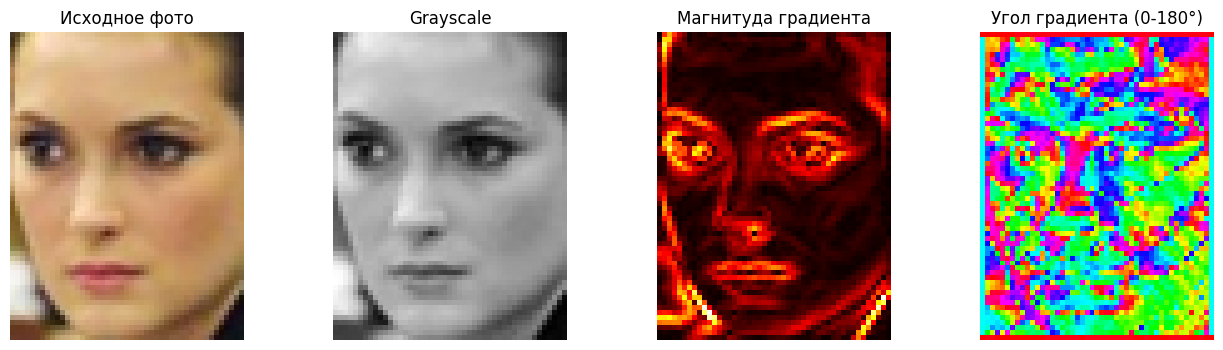

In [3]:
def to_gray(image_float):
    if len(image_float.shape) == 3:
        return (0.299*image_float[:,:,0] +
                0.587*image_float[:,:,1] +
                0.114*image_float[:,:,2]) * 255.0
    return image_float * 255.0

def compute_gradients(gray):
    Ix = np.zeros_like(gray)
    Iy = np.zeros_like(gray)
    Ix[:, 1:-1] = (gray[:, 2:] - gray[:, :-2]) / 2.0
    Iy[1:-1, :] = (gray[2:, :] - gray[:-2, :]) / 2.0
    magnitude = np.sqrt(Ix**2 + Iy**2)
    angle     = np.degrees(np.arctan2(Iy, Ix)) % 180.0
    return Ix, Iy, magnitude, angle

# Проверяем на первом изображении
sample = images_valid[0]
gray   = to_gray(sample)
Ix, Iy, magnitude, angle = compute_gradients(gray)

f, axarr = plt.subplots(1, 4, figsize=(16, 4))
axarr[0].imshow(sample)
axarr[0].set_title('Исходное фото')
axarr[1].imshow(gray, cmap='gray')
axarr[1].set_title('Grayscale')
axarr[2].imshow(magnitude, cmap='hot')
axarr[2].set_title('Магнитуда градиента')
axarr[3].imshow(angle, cmap='hsv')
axarr[3].set_title('Угол градиента (0-180°)')
for ax in axarr: ax.axis('off')
plt.show()

## Шаг 2: гистограммы по ячейкам
<p> Делим изображение на сетку ячеек cell_size * cell_size.
<p> В каждой ячейке накапливаем гистограмму из num_bins бинов:
<p> угол пикселя определяет в какой бин он попадает,
<p> а его магнитуда — насколько весомый вклад.

Сетка ячеек: 7×5, бинов: 9


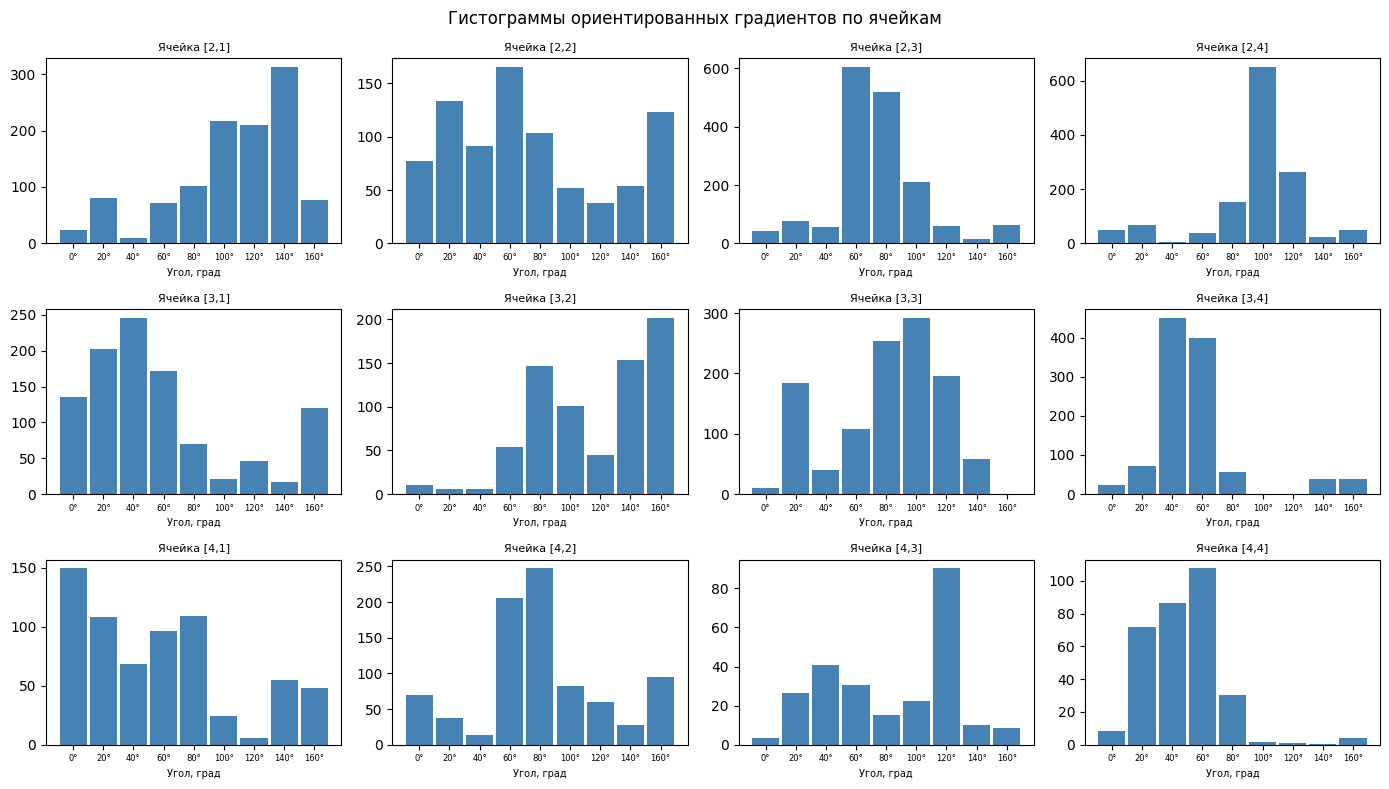

In [4]:
CELL_SIZE = 8
NUM_BINS  = 9
BIN_WIDTH = 180.0 / NUM_BINS  # 20° на бин

def build_cell_histograms(magnitude, angle, cell_size=8, num_bins=9):
    h, w   = magnitude.shape
    n_cy   = h // cell_size
    n_cx   = w // cell_size
    bw     = 180.0 / num_bins
    hists  = np.zeros((n_cy, n_cx, num_bins))

    for cy in range(n_cy):
        for cx in range(n_cx):
            r0, r1 = cy*cell_size, (cy+1)*cell_size
            c0, c1 = cx*cell_size, (cx+1)*cell_size
            cell_mag = magnitude[r0:r1, c0:c1]
            cell_ang = angle[r0:r1, c0:c1]
            hist, _ = np.histogram(cell_ang, bins=num_bins,
                                   range=(0, 180), weights=cell_mag)
            hists[cy, cx] = hist
    return hists

cell_hists = build_cell_histograms(magnitude, angle, CELL_SIZE, NUM_BINS)
print(f'Сетка ячеек: {cell_hists.shape[0]}×{cell_hists.shape[1]}, бинов: {NUM_BINS}')

f, axes = plt.subplots(3, 4, figsize=(14, 8))
bins_x = np.arange(NUM_BINS) * BIN_WIDTH
for i, ax in enumerate(axes.flat):
    cy = (i // 4) + 2
    cx = (i %  4) + 1
    ax.bar(bins_x, cell_hists[cy, cx], width=BIN_WIDTH*0.9, color='steelblue')
    ax.set_title(f'Ячейка [{cy},{cx}]', fontsize=8)
    ax.set_xlabel('Угол, град', fontsize=7)
    ax.set_xticks(bins_x)
    ax.set_xticklabels([f'{int(b)}°' for b in bins_x], fontsize=6)
plt.suptitle('Гистограммы ориентированных градиентов по ячейкам')
plt.tight_layout()
plt.show()

## Шаг 3: блочная нормализация и сборка финального дескриптора
<p> Объединяем соседние 2 * 2 ячейки в блок и нормируем вектор блока.
<p> Нормировка = деление на L2-норму + маленький eps, чтобы не делить на ноль.
<p> Это делает дескриптор инвариантным к освещению:
<p> при изменении яркости все магнитуды вырастут в K раз,
<p> но после нормировки вектор останется тем же.

In [5]:
BLOCK_SIZE = 2   # 2*2 ячейки = 16*16 пикселей

def normalize_blocks(cell_hists, block_size=2):
    n_cy, n_cx, num_bins = cell_hists.shape
    descriptor = []
    for by in range(n_cy - block_size + 1):
        for bx in range(n_cx - block_size + 1):
            block = cell_hists[by:by+block_size, bx:bx+block_size].flatten()
            norm  = np.sqrt(np.sum(block**2) + 1e-6)
            descriptor.append(block / norm)
    return np.concatenate(descriptor)

def hog_descriptor(image_float, cell_size=8, num_bins=9, block_size=2):
    gray  = to_gray(image_float)
    _, _, magnitude, angle = compute_gradients(gray)
    hists = build_cell_histograms(magnitude, angle, cell_size, num_bins)
    return normalize_blocks(hists, block_size)

desc_test = hog_descriptor(sample)
print(f'Размер HOG-дескриптора для патча {sample.shape[0]}×{sample.shape[1]}: {len(desc_test)}')

Размер HOG-дескриптора для патча 62×47: 864


# 4.3 Извлечение признаков из датасета

Вычисляем HOG-дескриптор для каждого изображения из датасета. Каждый дескриптор — это вектор признаков, который описывает одно лицо. Все дескрипторы складываем в матрицу `X` (образцы × признаки), метки пола — в вектор `y`.

Дополнительно нарезаем **негативные примеры** — случайные патчи из тех же фотографий, сдвинутые относительно центра лица. Это нужно для обучения детектора «лицо / не-лицо»: модель должна видеть и то, что не является лицом.

In [6]:
print('Вычисляем HOG-дескрипторы для лиц...')

X_faces = []
for i, img in enumerate(images_valid):
    X_faces.append(hog_descriptor(img))
    if (i+1) % 200 == 0:
        print(f'  {i+1}/{len(images_valid)}')

X_faces = np.array(X_faces)
y_gender = gender_labels.copy()

print(f'Матрица признаков (лица): {X_faces.shape}')
print(f'Метки пола: {y_gender.shape}, классы: {np.unique(y_gender)}')

Вычисляем HOG-дескрипторы для лиц...
  200/2026
  400/2026
  600/2026
  800/2026
  1000/2026
  1200/2026
  1400/2026
  1600/2026
  1800/2026
  2000/2026
Матрица признаков (лица): (2026, 864)
Метки пола: (2026,), классы: [0 1]


## Негативные примеры для детектора лицо/не-лицо

Негативные примеры — патчи, которые **не содержат лица**. Детектору нужно видеть оба класса иначе он не научится отличать одно от другого.

Проблема наивного подхода (2 картинки из `load_sample_images`): из двух источников нарезается очень мало уникальных патчей, и тренировочная и тестовая выборка получают одинаковые или похожие примеры — SVM их просто запоминает, отсюда метрики 0.999–1.0.

Решение — **синтетические негативы из самого LFW**: берём тысячи фотографий лиц и создаём из них патчи, которые заведомо не являются лицом:
- переворот вертикально и горизонтально — нарушает структуру лица
- поворот на 90° и 180°
- сильно смещённый кроп (угол кадра — там фон, плечи, стена)
- случайный гауссовый шум

Каждый тип трансформации применяется к разным исходным изображениям → негативы максимально разнообразны → утечки данных между train/test нет.

Генерируем негативные примеры из LFW (6 типов трансформаций)...
Вычисляем HOG для негативных примеров...
  500/2026
  1000/2026
  1500/2026
  2000/2026
Негативных примеров: (2026, 864)
Всего для детектора: (4052, 864)
  лиц: 2026,  не-лиц: 2026


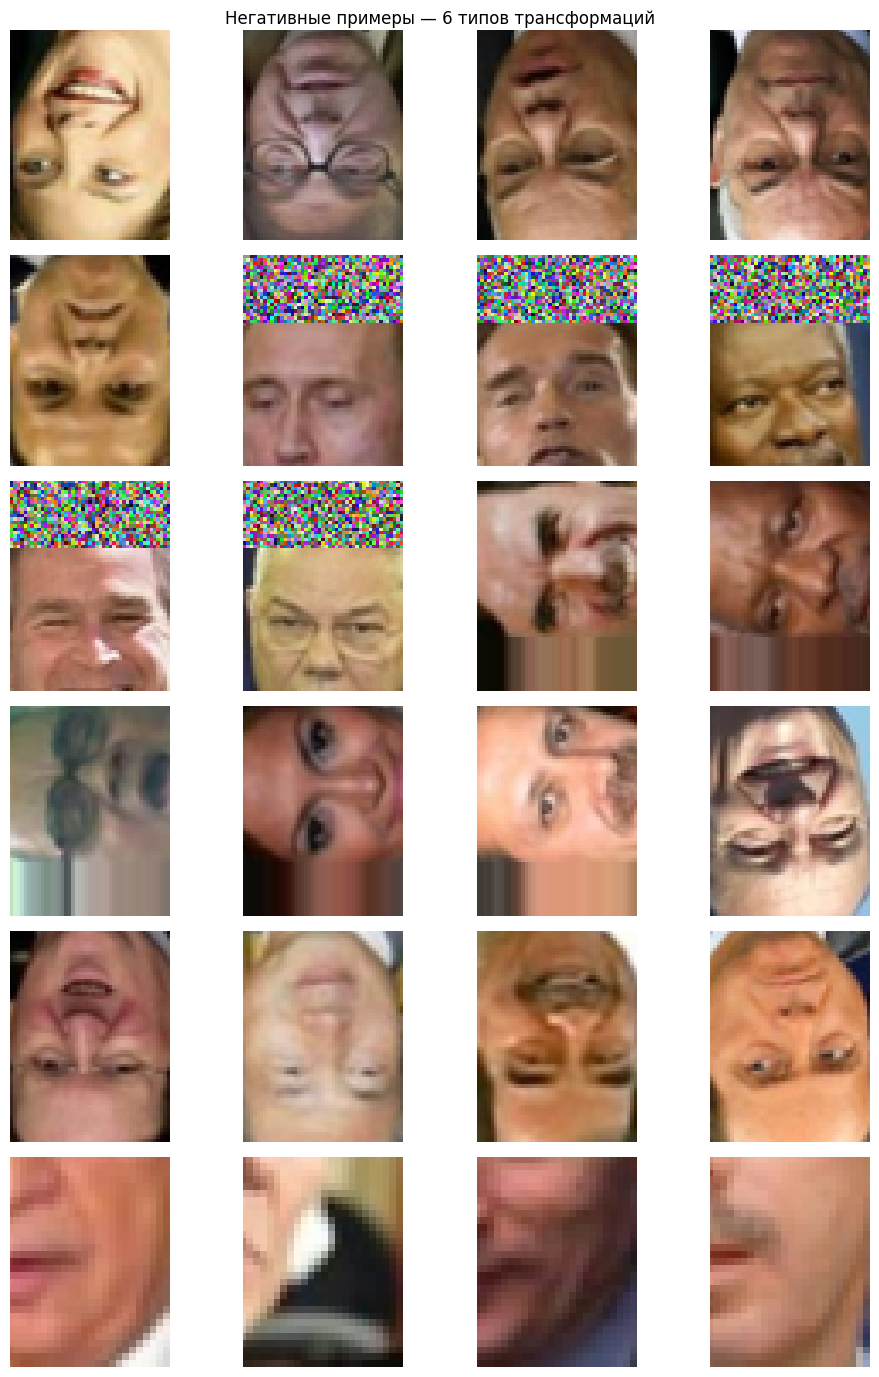

In [7]:
# Размеры патча — берём из LFW
img_h, img_w = lfw.images.shape[1], lfw.images.shape[2]
N_NEG = len(images_valid)   # столько же негативов, сколько позитивов

# Источник: ВСЕ изображения LFW (тысячи уникальных фото)
all_imgs = lfw.images  # float32, 0..1, shape (N, H, W, 3)
np.random.seed(42)

def make_negatives(all_imgs, img_h, img_w, n_total):
    """
    Генерирует n_total негативных патчей из массива изображений.
    Использует 6 типов трансформаций — каждая гарантированно
    разрушает структуру лица и создаёт уникальный пример.
    """
    n_imgs   = len(all_imgs)
    per_type = n_total // 6 + 1
    negatives = []

    # Перемешиваем индексы чтобы каждый тип брал разные исходники
    idx = np.random.permutation(n_imgs)

    # 1. Вертикальный переворот — нос смотрит вверх, лоб внизу
    for i in range(per_type):
        patch = all_imgs[idx[i % n_imgs]].copy()
        negatives.append(patch[::-1, :, :])          # flip rows

    # 2. Горизонтальный переворот — зеркало. Само по себе лицо,
    #    но после flip+комбо с другими аугментациями — странно
    #    Нет — горизонтальный флип лица ОСТАЁТСЯ лицом. Заменяем
    #    на: flip + вертикальный сдвиг на 30% высоты (срезаем лоб)
    for i in range(per_type):
        patch = all_imgs[idx[(i + per_type) % n_imgs]].copy()
        shift = max(1, img_h // 3)
        # сдвигаем вниз — верх заполняем шумом, лицо обрезается
        shifted = np.zeros_like(patch)
        shifted[shift:, :, :] = patch[:img_h - shift, :, :]
        shifted[:shift, :, :]  = np.random.rand(shift, img_w, 3).astype(np.float32)
        negatives.append(shifted)

    # 3. Поворот на 90° — ориентация полностью нарушена
    for i in range(per_type):
        patch = all_imgs[idx[(i + 2*per_type) % n_imgs]].copy()
        # транспонируем H и W, потом resize обратно до img_h x img_w
        rotated = np.transpose(patch, (1, 0, 2))  # (W, H, 3)
        rotated = rotated[:img_h, :img_w, :] if rotated.shape[0] >= img_h and rotated.shape[1] >= img_w \
                  else np.pad(rotated, ((0, max(0, img_h-rotated.shape[0])),
                                        (0, max(0, img_w-rotated.shape[1])),
                                        (0, 0)), mode='edge')[:img_h, :img_w, :]
        negatives.append(rotated)

    # 4. Поворот на 180° (перевёрнутое лицо)
    for i in range(per_type):
        patch = all_imgs[idx[(i + 3*per_type) % n_imgs]].copy()
        negatives.append(patch[::-1, ::-1, :])    # flip обеих осей

    # 5. Угловой кроп — берём угол изображения где нет лица
    #    LFW кадрированы по лицу, поэтому угол = фон/плечи
    for i in range(per_type):
        # Источник — бОльшие изображения: масштабируем патч вверх
        src = all_imgs[idx[(i + 4*per_type) % n_imgs]]
        big = np.kron(src, np.ones((2, 2, 1)))     # удваиваем билинейно через kron
        h_b, w_b = big.shape[:2]
        # Берём правый нижний угол
        r0 = h_b - img_h
        c0 = w_b - img_w
        negatives.append(np.clip(big[r0:r0+img_h, c0:c0+img_w, :], 0, 1).astype(np.float32))

    # 6. Чистый гауссовый шум — нет никакой структуры вообще
    for i in range(per_type):
        noise = np.random.rand(img_h, img_w, 3).astype(np.float32)
        negatives.append(noise)

    return negatives[:n_total]


print('Генерируем негативные примеры из LFW (6 типов трансформаций)...')
neg_patches = make_negatives(all_imgs, img_h, img_w, N_NEG)

print('Вычисляем HOG для негативных примеров...')
X_neg = []
for i, patch in enumerate(neg_patches):
    X_neg.append(hog_descriptor(patch))
    if (i+1) % 500 == 0:
        print(f'  {i+1}/{N_NEG}')

X_neg    = np.array(X_neg)
y_neg    = np.full(N_NEG, -1)

print(f'Негативных примеров: {X_neg.shape}')

X_detect = np.vstack([X_faces, X_neg])
y_detect = np.concatenate([np.ones(len(X_faces), dtype=int), y_neg])

print(f'Всего для детектора: {X_detect.shape}')
print(f'  лиц: {(y_detect==1).sum()},  не-лиц: {(y_detect==-1).sum()}')

# Проверяем разнообразие: показываем по 4 примера каждого типа
labels_types = ['вертик. флип', 'сдвиг вниз', 'поворот 90°',
                 'поворот 180°', 'угловой кроп', 'шум']
per_type = N_NEG // 6
f, axes = plt.subplots(6, 4, figsize=(10, 14))
for t in range(6):
    for j in range(4):
        axes[t, j].imshow(np.clip(neg_patches[t * per_type + j], 0, 1))
        axes[t, j].axis('off')
    axes[t, 0].set_ylabel(labels_types[t], fontsize=9)
plt.suptitle('Негативные примеры — 6 типов трансформаций')
plt.tight_layout()
plt.show()


# 4.4 Обучение SVM

Обучаем два независимых классификатора:

**Детектор** — бинарный классификатор `лицо (1) / не-лицо (-1)`. По нему скользящее окно решает, есть ли в патче лицо.

**Классификатор пола** — бинарный классификатор `мужчина (0) / женщина (1)`. Применяется только к тем патчам, которые детектор уже признал лицом.

Оба используют `LinearSVC` — линейный SVM. Идея: в пространстве HOG-признаков лица и не-лица линейно разделимы. SVM находит гиперплоскость с максимальным зазором между классами — это делает его устойчивым к небольшим вариациям входных данных.

Перед обучением масштабируем признаки через `StandardScaler` — вычитаем среднее и делим на стандартное отклонение. Без этого SVM работает хуже, потому что бины с большими значениями доминируют.

## Классификатор лица: лицо/ не-лицо

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_detect, y_detect, test_size=0.2, random_state=42, stratify=y_detect
)

print('Обучаем детектор лицо/не-лицо...')
detector_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=0.1, max_iter=2000))
])
detector_pipe.fit(X_tr, y_tr)

y_pred = detector_pipe.predict(X_te)
acc    = accuracy_score(y_te, y_pred)
print(f'Точность детектора на тесте: {acc:.3f}')
print(classification_report(y_te, y_pred, target_names=['не-лицо', 'лицо']))

Обучаем детектор лицо/не-лицо...
Точность детектора на тесте: 0.994
              precision    recall  f1-score   support

     не-лицо       1.00      0.99      0.99       406
        лицо       0.99      1.00      0.99       405

    accuracy                           0.99       811
   macro avg       0.99      0.99      0.99       811
weighted avg       0.99      0.99      0.99       811



## Классификатор пола: мужчина / женщина
<p> Обучаем только на лицах (X_faces, y_gender)

In [9]:
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_faces, y_gender, test_size=0.2, random_state=42, stratify=y_gender
)

print('Обучаем классификатор пола...')
gender_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=1.0, max_iter=2000))
])
gender_pipe.fit(X_tr_g, y_tr_g)

y_pred_g = gender_pipe.predict(X_te_g)
acc_g    = accuracy_score(y_te_g, y_pred_g)
print(f'Точность классификатора пола на тесте: {acc_g:.3f}')
print(classification_report(y_te_g, y_pred_g, target_names=['мужчина', 'женщина']))

# Сохраняем модели чтобы не переобучать каждый раз
with open('detector_model.pkl', 'wb') as f:
    pickle.dump(detector_pipe, f)
with open('gender_model.pkl', 'wb') as f:
    pickle.dump(gender_pipe, f)
print('Модели сохранены в .pkl')

Обучаем классификатор пола...
Точность классификатора пола на тесте: 0.943
              precision    recall  f1-score   support

     мужчина       0.97      0.96      0.97       370
     женщина       0.67      0.72      0.69        36

    accuracy                           0.94       406
   macro avg       0.82      0.84      0.83       406
weighted avg       0.95      0.94      0.94       406

Модели сохранены в .pkl


/Users/arseniikostin/cv-labs-sem8/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# 4.5 Скользящее окно и пирамида масштабов

Детектор обучен на патчах фиксированного размера. Чтобы находить лица разного размера на произвольном изображении, применяем две идеи:

**Пирамида масштабов** — уменьшаем изображение в несколько раз (каждый раз на scale=0.85). На каждом масштабе запускаем скользящее окно. Так маленькое окно «видит» и большие лица (на уменьшенном изображении они тоже маленькие).

**Скользящее окно** — перемещаем окно с шагом `step` по строкам и столбцам. Для каждой позиции вычисляем HOG и спрашиваем детектор: лицо?

**Non-Maximum Suppression (NMS)** — одно лицо порождает десятки срабатываний от соседних позиций. NMS оставляет только прямоугольник с наибольшей уверенностью (`decision_function`) среди всех перекрывающихся. Перекрытие измеряем через IoU (Intersection over Union) — отношение площади пересечения к площади объединения двух bbox.

In [10]:
def sliding_window(image_uint8, win_h, win_w, step=16):
    h, w = image_uint8.shape[:2]
    for r in range(0, h - win_h + 1, step):
        for c in range(0, w - win_w + 1, step):
            patch = image_uint8[r:r+win_h, c:c+win_w]
            yield r, c, patch


def image_pyramid(image_uint8, scale=0.85, min_size=64):
    img    = image_uint8.copy()
    factor = 1.0
    while True:
        yield img, factor
        h, w   = img.shape[:2]
        new_h  = int(h * scale)
        new_w  = int(w * scale)
        if new_h < min_size or new_w < min_size:
            break
        img    = cv2.resize(img, (new_w, new_h))
        factor *= scale


def iou(boxA, boxB):
    r0 = max(boxA[0], boxB[0]);  c0 = max(boxA[1], boxB[1])
    r1 = min(boxA[2], boxB[2]);  c1 = min(boxA[3], boxB[3])
    inter = max(0, r1-r0) * max(0, c1-c0)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def nms(detections, iou_thresh=0.3):
    if not detections:
        return []
    detections = sorted(detections, key=lambda x: x[0], reverse=True)
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [
            d for d in detections
            if iou(best[1:], d[1:]) < iou_thresh
        ]
    return kept


def detect_and_classify(image_uint8, detector, gender_clf,
                        win_h, win_w, step=16, scale=0.85,
                        det_threshold=0.5, iou_thresh=0.3):
    detections = []

    for img_scaled, factor in image_pyramid(image_uint8, scale=scale):
        for r, c, patch in sliding_window(img_scaled, win_h, win_w, step):
            patch_f = patch.astype(np.float32) / 255.0
            desc    = hog_descriptor(patch_f).reshape(1, -1)
            score   = detector.decision_function(desc)[0]
            if score > det_threshold:
                # переводим координаты обратно в исходный масштаб
                r0 = int(r / factor);  c0 = int(c / factor)
                r1 = int((r+win_h) / factor);  c1 = int((c+win_w) / factor)
                detections.append((score, r0, c0, r1, c1))

    # дубли
    detections = nms(detections, iou_thresh)

    results = []
    for score, r0, c0, r1, c1 in detections:
        face_crop = image_uint8[r0:r1, c0:c1]
        if face_crop.size == 0:
            continue
        face_resized = cv2.resize(face_crop, (win_w, win_h))
        face_f  = face_resized.astype(np.float32) / 255.0
        desc    = hog_descriptor(face_f).reshape(1, -1)
        gender  = gender_clf.predict(desc)[0]  # 0=муж, 1=жен
        results.append((r0, c0, r1, c1, gender))

    return results

WIN_H = images_valid.shape[1]
WIN_W = images_valid.shape[2]
print(f'Размер окна детектора: {WIN_H}×{WIN_W} пикселей')

Размер окна детектора: 62×47 пикселей


# 4.6 Тестирование на фотографиях

Запускаем полный конвейер на нескольких примерах из датасета, которые модель не видела при обучении (тестовая выборка). Отображаем bbox и метку пола. Красный — мужчина, синий — женщина.

`det_threshold` — порог уверенности детектора. Чем выше, тем меньше ложных срабатываний, но и больше пропусков. Подбирается экспериментально.

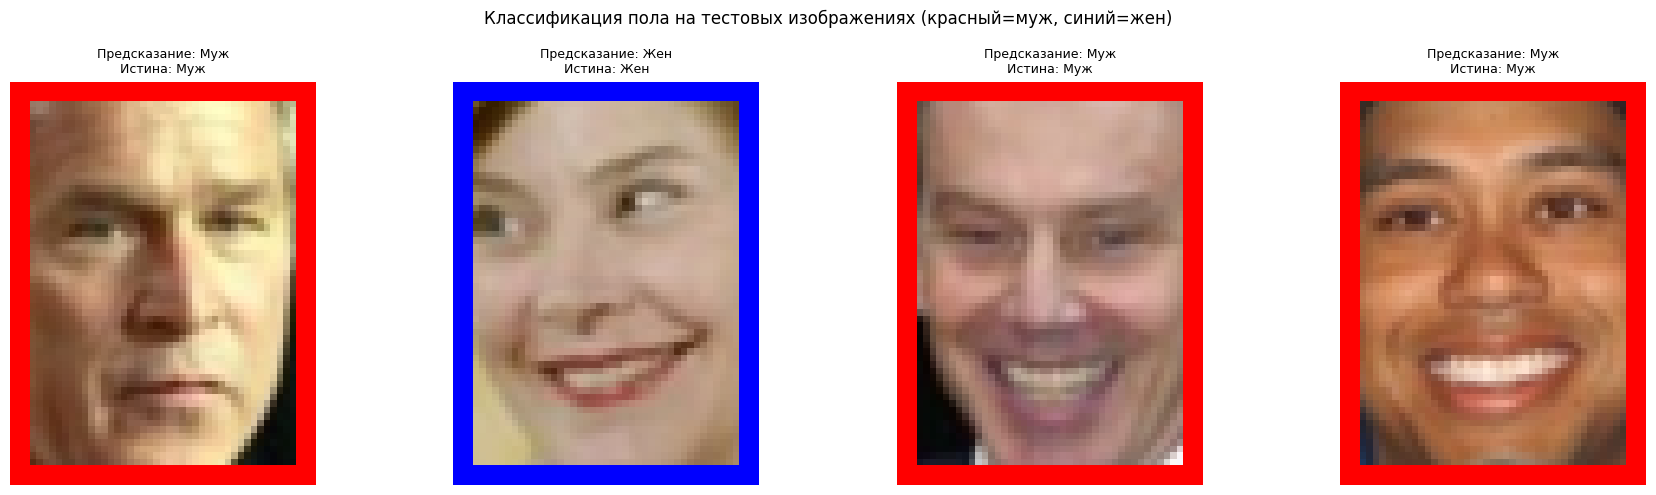

In [11]:
def draw_results(image_uint8, results):
    img = image_uint8.copy()
    for (r0, c0, r1, c1, gender) in results:
        color  = [255, 0, 0] if gender == 0 else [0, 0, 255]
        label  = 'M' if gender == 0 else 'F'

        img[r0, c0:c1] = color
        img[r1, c0:c1] = color
        img[r0:r1, c0] = color
        img[r0:r1, c1] = color

        cv2.putText(img, label, (c0+2, r0+12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img


test_imgs_idx = np.random.choice(len(X_te_g), 4, replace=False)

f, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, idx in enumerate(test_imgs_idx):
    orig_idx  = valid_indices[list(range(len(images_valid)))[idx]]
    image_u8  = (lfw.images[orig_idx] * 255).astype(np.uint8)

    desc   = X_faces[idx].reshape(1, -1)
    pred_g = gender_pipe.predict(desc)[0]
    true_g = y_gender[idx]

    color_border = [255, 0, 0] if pred_g == 0 else [0, 0, 255]
    img_show = image_u8.copy()
    img_show[0:3, :] = color_border
    img_show[-3:, :] = color_border
    img_show[:, 0:3] = color_border
    img_show[:, -3:] = color_border

    label_pred = 'Муж' if pred_g == 0 else 'Жен'
    label_true = 'Муж' if true_g == 0 else 'Жен'

    axes[i].imshow(img_show)
    axes[i].set_title(f'Предсказание: {label_pred}\nИстина: {label_true}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Классификация пола на тестовых изображениях (красный=муж, синий=жен)')
plt.tight_layout()
plt.show()

# 4.7 Детектирование в реальном времени с веб-камеры

Живая камера вынесена в отдельный скрипт  — он открывает окно cv2 и работает пока не нажать **Q**.

Скрипт читает сохранённые модели (, ) из текущей директории — они сохраняются после выполнения ячейки 4.4. Поэтому перед запуском скрипта убедитесь что ячейки 4.1–4.4 выполнены.

**Запуск из терминала:**


Параметры в начале скрипта:
-  — индекс камеры (2 для MacBook)
-  — порог детектора, снизить до 0.0 если лицо не находится
-  — шаг скользящего окна, больше = быстрее но грубее
-  — масштаб входного кадра (0.4–0.6 для скорости)


# 4.8 Итоговая оценка качества

Проверяем точность обоих классификаторов на тестовой выборке, которую модель не видела при обучении. Строим матрицу ошибок — она показывает, какие классы модель путает между собой.

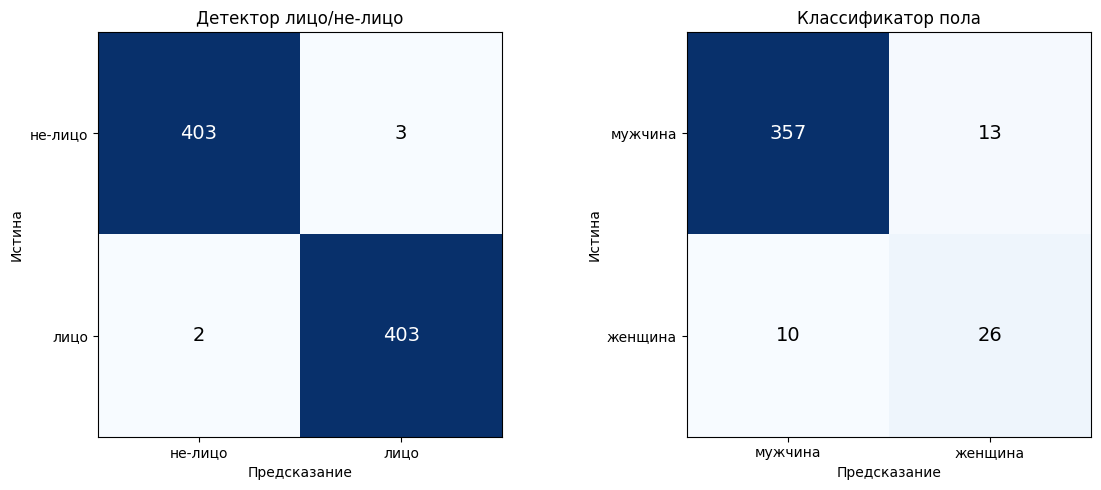

Точность детектора:          0.994
Точность классификатора пола: 0.943


In [12]:
from sklearn.metrics import confusion_matrix

# детектор
y_pred_det = detector_pipe.predict(X_te)
cm_det     = confusion_matrix(y_te, y_pred_det, labels=[-1, 1])

# классификатор пола
y_pred_gen = gender_pipe.predict(X_te_g)
cm_gen     = confusion_matrix(y_te_g, y_pred_gen, labels=[0, 1])

f, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title, labels in [
    (axes[0], cm_det, 'Детектор лицо/не-лицо', ['не-лицо', 'лицо']),
    (axes[1], cm_gen, 'Классификатор пола',    ['мужчина', 'женщина'])
]:
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_ylabel('Истина')
    ax.set_xlabel('Предсказание')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=14)

plt.tight_layout()
plt.show()

print(f'Точность детектора:          {accuracy_score(y_te, y_pred_det):.3f}')
print(f'Точность классификатора пола: {accuracy_score(y_te_g, y_pred_gen):.3f}')

# Вывод

В ходе лабораторной работы реализован полный конвейер детектирования лиц и классификации пола на основе метода HOG + Linear SVM.

HOG-дескриптор вычисляется вручную через градиенты (центральные разности, как в лабе 2), гистограммы ориентаций по ячейкам и блочную L2-нормировку. Детектор на основе LinearSVC разделяет патчи на «лицо» и «не-лицо» в пространстве HOG-признаков. Второй SVM классифицирует пол. Для локализации лиц на произвольных изображениях применяется пирамида масштабов и скользящее окно, дублирующиеся срабатывания убираются через NMS с порогом IoU.

Метод выбран как баланс между простотой объяснения (градиенты, гистограммы, линейный классификатор) и реальной эффективностью — HOG+SVM является классическим промышленным подходом до эпохи глубокого обучения и до сих пор применяется в задачах с ограниченными ресурсами.